In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("Air_Quality.csv")

In [4]:
print("First 5 Rows:")
print(df.head())


First 5 Rows:
   Unique ID  Indicator ID                    Name Measure Measure Info  \
0     172653           375  Nitrogen dioxide (NO2)    Mean          ppb   
1     172585           375  Nitrogen dioxide (NO2)    Mean          ppb   
2     336637           375  Nitrogen dioxide (NO2)    Mean          ppb   
3     336622           375  Nitrogen dioxide (NO2)    Mean          ppb   
4     172582           375  Nitrogen dioxide (NO2)    Mean          ppb   

  Geo Type Name  Geo Join ID                      Geo Place Name  \
0         UHF34          203  Bedford Stuyvesant - Crown Heights   
1         UHF34          203  Bedford Stuyvesant - Crown Heights   
2         UHF34          204                       East New York   
3         UHF34          103                  Fordham - Bronx Pk   
4         UHF34          104                Pelham - Throgs Neck   

           Time Period  Start_Date  Data Value  Message  
0  Annual Average 2011  12/01/2010       25.30      NaN  
1  Annual 

In [5]:
print("\nDataset Information:")
print(df.info())



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16218 entries, 0 to 16217
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unique ID       16218 non-null  int64  
 1   Indicator ID    16218 non-null  int64  
 2   Name            16218 non-null  object 
 3   Measure         16218 non-null  object 
 4   Measure Info    16218 non-null  object 
 5   Geo Type Name   16218 non-null  object 
 6   Geo Join ID     16218 non-null  int64  
 7   Geo Place Name  16218 non-null  object 
 8   Time Period     16218 non-null  object 
 9   Start_Date      16218 non-null  object 
 10  Data Value      16218 non-null  float64
 11  Message         0 non-null      float64
dtypes: float64(2), int64(3), object(7)
memory usage: 1.5+ MB
None


In [16]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Unique ID         0
Indicator ID      0
Name              0
Measure           0
Measure Info      0
Geo Type Name     0
Geo Join ID       0
Geo Place Name    0
Time Period       0
Start_Date        0
Data Value        0
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)
display(df.head())

In [23]:
for col in df.select_dtypes(include='object').columns:
    df[col].fillna('Unknown', inplace=True)
display(df.head())

/tmp/ipykernel_1526/608005740.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value
0,172653,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,203,Bedford Stuyvesant - Crown Heights,Annual Average 2011,01-Dec-2010,25.30
1,172585,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,203,Bedford Stuyvesant - Crown Heights,Annual Average 2009,01-Dec-2008,26.93
2,336637,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,204,East New York,Annual Average 2015,01-Jan-2015,19.09
3,336622,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,103,Fordham - Bronx Pk,Annual Average 2015,01-Jan-2015,19.76
4,172582,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,104,Pelham - Throgs Neck,Annual Average 2009,01-Dec-2008,22.83


In [25]:
df['Data Value'] = pd.to_numeric(df['Data Value'], errors='coerce')
df['Data Value'] = df['Data Value'].fillna(0).astype(int)
display(df.head())

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value
0,172653,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,203,Bedford Stuyvesant - Crown Heights,Annual Average 2011,01-Dec-2010,25
1,172585,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,203,Bedford Stuyvesant - Crown Heights,Annual Average 2009,01-Dec-2008,26
2,336637,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,204,East New York,Annual Average 2015,01-Jan-2015,19
3,336622,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,103,Fordham - Bronx Pk,Annual Average 2015,01-Jan-2015,19
4,172582,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,104,Pelham - Throgs Neck,Annual Average 2009,01-Dec-2008,22


In [21]:
df['Start_Date'] = pd.to_datetime(df['Start_Date'])
df['Start_Date'] = df['Start_Date'].dt.strftime('%d-%b-%Y')
display(df.head())

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value
0,172653,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,203,Bedford Stuyvesant - Crown Heights,Annual Average 2011,01-Dec-2010,25.30
1,172585,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,203,Bedford Stuyvesant - Crown Heights,Annual Average 2009,01-Dec-2008,26.93
2,336637,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,204,East New York,Annual Average 2015,01-Jan-2015,19.09
3,336622,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,103,Fordham - Bronx Pk,Annual Average 2015,01-Jan-2015,19.76
4,172582,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,104,Pelham - Throgs Neck,Annual Average 2009,01-Dec-2008,22.83


In [27]:
df['Year'] = pd.to_datetime(df['Start_Date']).dt.year
display(df.head())

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Year
0,172653,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,203,Bedford Stuyvesant - Crown Heights,Annual Average 2011,01-Dec-2010,25,2010
1,172585,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,203,Bedford Stuyvesant - Crown Heights,Annual Average 2009,01-Dec-2008,26,2008
2,336637,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,204,East New York,Annual Average 2015,01-Jan-2015,19,2015
3,336622,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,103,Fordham - Bronx Pk,Annual Average 2015,01-Jan-2015,19,2015
4,172582,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,104,Pelham - Throgs Neck,Annual Average 2009,01-Dec-2008,22,2008


In [28]:
df['Month'] = pd.to_datetime(df['Start_Date']).dt.month
display(df.head())

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Year,Month
0,172653,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,203,Bedford Stuyvesant - Crown Heights,Annual Average 2011,01-Dec-2010,25,2010,12
1,172585,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,203,Bedford Stuyvesant - Crown Heights,Annual Average 2009,01-Dec-2008,26,2008,12
2,336637,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,204,East New York,Annual Average 2015,01-Jan-2015,19,2015,1
3,336622,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,103,Fordham - Bronx Pk,Annual Average 2015,01-Jan-2015,19,2015,1
4,172582,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,104,Pelham - Throgs Neck,Annual Average 2009,01-Dec-2008,22,2008,12


In [29]:
def category(value):
    if value <= 20:
        return 'Low'
    elif value <= 40:
        return 'Moderate'
    else:
        return 'High'

df['AQ_Category'] = df['Data Value'].apply(category)
display(df.head())

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Year,Month,AQ_Category
0,172653,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,203,Bedford Stuyvesant - Crown Heights,Annual Average 2011,01-Dec-2010,25,2010,12,Moderate
1,172585,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,203,Bedford Stuyvesant - Crown Heights,Annual Average 2009,01-Dec-2008,26,2008,12,Moderate
2,336637,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,204,East New York,Annual Average 2015,01-Jan-2015,19,2015,1,Low
3,336622,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,103,Fordham - Bronx Pk,Annual Average 2015,01-Jan-2015,19,2015,1,Low
4,172582,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,104,Pelham - Throgs Neck,Annual Average 2009,01-Dec-2008,22,2008,12,Moderate


In [ ]:
print("Number of Records:", len(df))
print("Number of Columns:", len(df.columns))
print("Unique Indicators:", df['Name'].nunique())

Number of Records: 9092
Number of Columns: 13
Unique Indicators: 19


In [ ]:
print("Number of Locations:",
      df['Geo Place Name'].nunique())

print("\nTop 10 Locations:")
print(df['Geo Place Name'].value_counts().head(10))

Number of Locations: 113

Top 10 Locations:
Geo Place Name
Southwest Queens              207
Flushing - Clearview          202
Rockaways                     202
Ridgewood - Forest Hills      188
Jamaica                       187
Southeast Queens              178
West Queens                   176
Long Island City - Astoria    158
East Harlem                   152
Borough Park                  145
Name: count, dtype: int64


In [ ]:
print("Earliest Record Date:",
      df['Start_Date'].min())

print("Latest Record Date:",
      df['Start_Date'].max())

print("Years Available in Dataset:")
print(sorted(df['Year'].unique()))

Earliest Record Date: 2005-01-01 00:00:00
Latest Record Date: 2021-06-01 00:00:00
Years Available in Dataset:
[np.float64(2005.0), np.float64(2008.0), np.float64(2009.0), np.float64(2010.0), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(nan)]


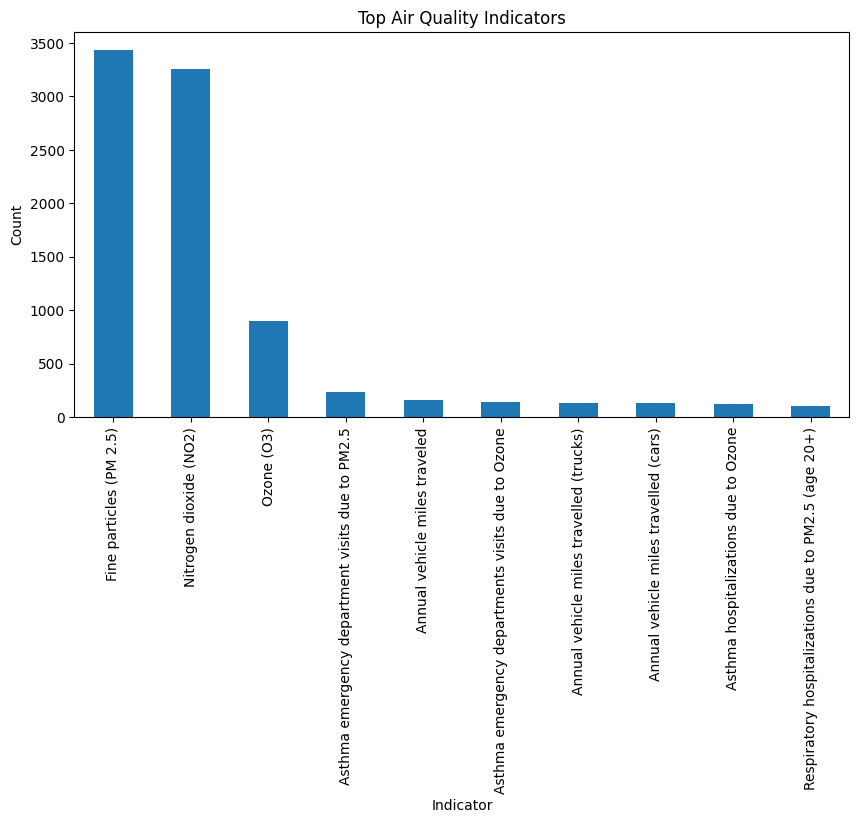

In [ ]:
df['Name'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Air Quality Indicators")
plt.xlabel("Indicator")
plt.ylabel("Count")
plt.show()


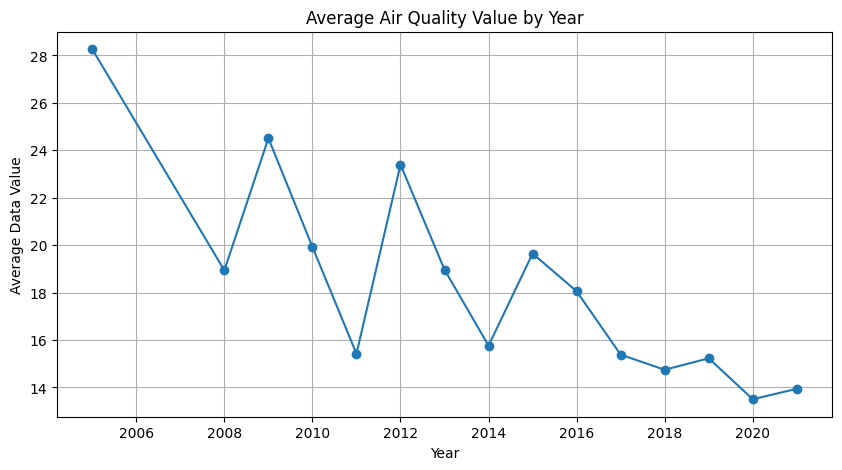

In [ ]:
yearly_avg = df.groupby('Year')['Data Value'].mean()

plt.figure(figsize=(10,5))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o')
plt.title("Average Air Quality Value by Year")
plt.xlabel("Year")
plt.ylabel("Average Data Value")
plt.grid(True)
plt.show()

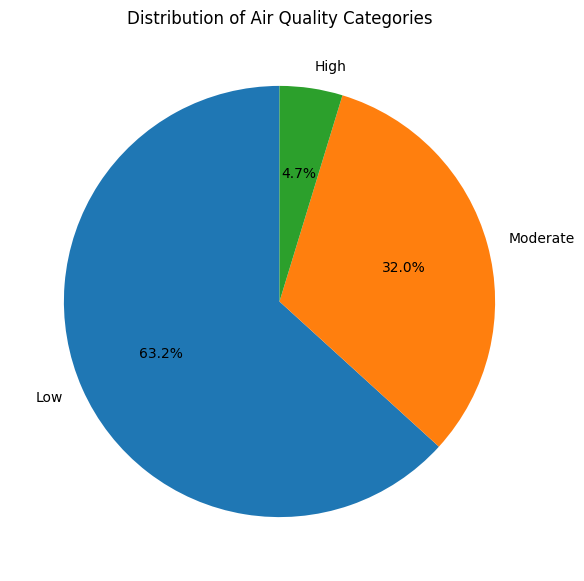

In [31]:
def category(value):
    if value <= 20:
        return 'Low'
    elif value <= 40:
        return 'Moderate'
    else:
        return 'High'

df['AQ_Category'] = df['Data Value'].apply(category)
category_counts = df['AQ_Category'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribution of Air Quality Categories')
plt.show()

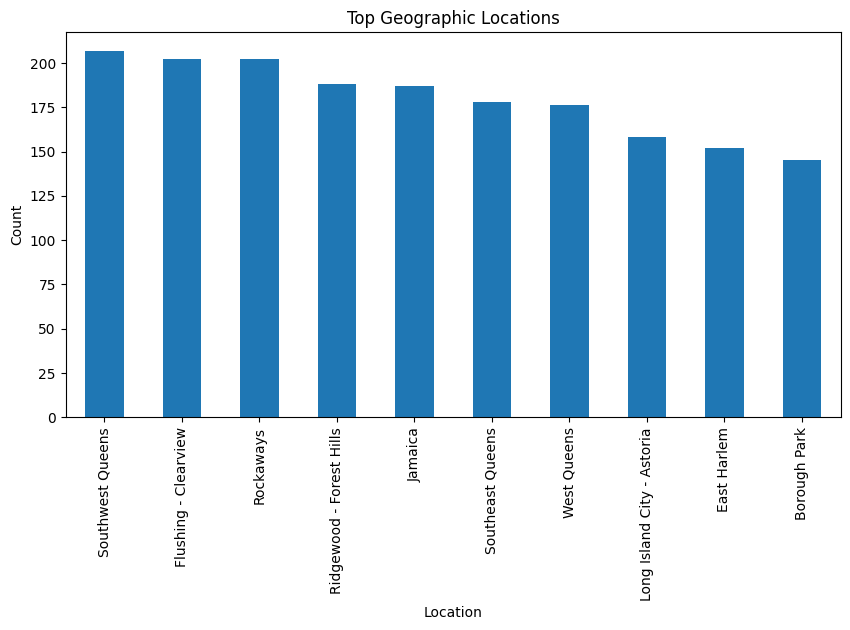

In [ ]:
df['Geo Place Name'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Geographic Locations")
plt.xlabel("Location")
plt.ylabel("Count")
plt.show()

In [ ]:
print("Average Data Value:", round(df['Data Value'].mean(), 2))
print("Maximum Data Value:", df['Data Value'].max())
print("Minimum Data Value:", df['Data Value'].min())
print("Most Common Indicator:", df['Name'].value_counts().idxmax())
print("Most Frequent Location:", df['Geo Place Name'].value_counts().idxmax())


Average Data Value: 18.6
Maximum Data Value: 424.7
Minimum Data Value: 0.0
Most Common Indicator: Fine particles (PM 2.5)
Most Frequent Location: Southwest Queens


In [ ]:
print("Conclusion:")
print("Air quality varies across locations and years.")
print("EDA helps identify pollution trends and areas needing attention.")

Conclusion:
Air quality varies across locations and years.
EDA helps identify pollution trends and areas needing attention.


In [32]:
df.to_csv("Final_AQI.csv")